=== Urban Green Space Optimization for Tropical Heat Island Control ===

Running genetic algorithm optimization...
Starting genetic algorithm optimization...
Generation 10: Score = 235.87
Generation 20: Score = 234.73
Generation 30: Score = 227.11
Generation 40: Score = 227.11
Generation 50: Score = 227.11
Generation 60: Score = 227.11
Generation 70: Score = 225.44
Generation 80: Score = 225.44
Genetic Algorithm Results: Score = 225.44

=== OPTIMIZATION REPORT ===
Maximum temperature reduction: 4.35°C
Average temperature reduction: 2.69°C
Total green spaces: 12
Green coverage: 2.4%
Temperature variance reduction: 2.56


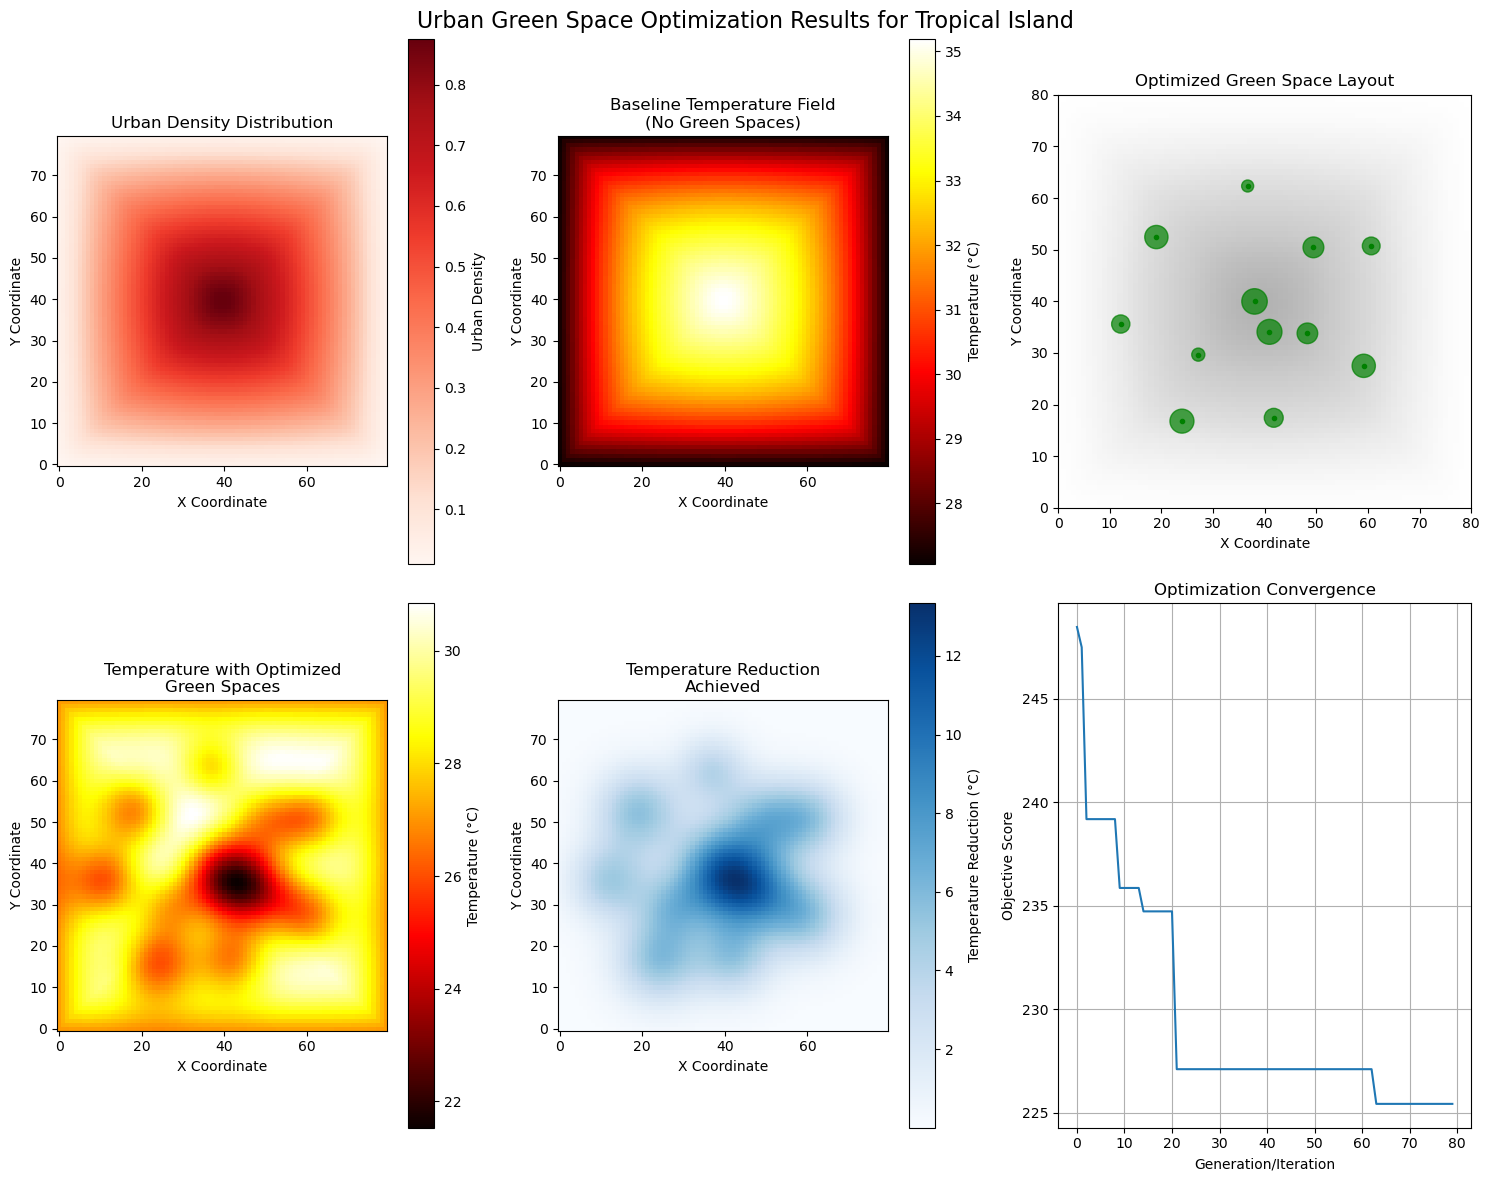

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution, minimize
from scipy.spatial.distance import cdist
from scipy.ndimage import gaussian_filter
import random
from dataclasses import dataclass
from typing import List, Tuple, Dict
import seaborn as sns

@dataclass
class GreenSpaceConfig:
    """Configuration for green space optimization"""
    grid_size: int = 100
    num_green_spaces: int = 15
    min_green_size: float = 0.5
    max_green_size: float = 3.0
    cooling_radius: float = 8.0
    base_temperature: float = 32.0  # Celsius for tropical climate
    urban_heat_intensity: float = 5.0
    wind_direction: float = 45.0  # degrees
    wind_speed: float = 3.0  # m/s

class TropicalHeatIslandModel:
    """Model for simulating urban heat island effects on tropical islands"""
    
    def __init__(self, config: GreenSpaceConfig):
        self.config = config
        self.grid = np.zeros((config.grid_size, config.grid_size))
        self.temperature_field = np.full((config.grid_size, config.grid_size), 
                                       config.base_temperature)
        self.urban_density = self._generate_urban_density()
        self.coastal_effect = self._generate_coastal_cooling()
        
    def _generate_urban_density(self) -> np.ndarray:
        """Generate urban density map with higher density inland"""
        x = np.linspace(0, 1, self.config.grid_size)
        y = np.linspace(0, 1, self.config.grid_size)
        X, Y = np.meshgrid(x, y)
        
        # Higher density in center, lower near edges (coast)
        center_x, center_y = 0.5, 0.5
        distance_from_center = np.sqrt((X - center_x)**2 + (Y - center_y)**2)
        distance_from_edge = np.minimum.reduce([X, Y, 1-X, 1-Y])
        
        # Combine center attraction with edge avoidance
        density = (1 - distance_from_center) * (1 - np.exp(-distance_from_edge * 5))
        return gaussian_filter(density, sigma=2)
    
    def _generate_coastal_cooling(self) -> np.ndarray:
        """Generate cooling effect from coastal areas"""
        x = np.linspace(0, 1, self.config.grid_size)
        y = np.linspace(0, 1, self.config.grid_size)
        X, Y = np.meshgrid(x, y)
        
        # Distance from nearest edge (coast)
        distance_from_coast = np.minimum.reduce([X, Y, 1-X, 1-Y])
        
        # Cooling effect decreases with distance from coast
        coastal_cooling = 3.0 * np.exp(-distance_from_coast * 8)
        return coastal_cooling
    
    def calculate_temperature_field(self, green_spaces: List[Tuple[float, float, float]]) -> np.ndarray:
        """Calculate temperature field given green space locations and sizes"""
        # Start with base temperature plus urban heating
        temp_field = (self.config.base_temperature + 
                     self.config.urban_heat_intensity * self.urban_density - 
                     self.coastal_effect)
        
        # Apply cooling from green spaces
        for x, y, size in green_spaces:
            if 0 <= x < self.config.grid_size and 0 <= y < self.config.grid_size:
                cooling_effect = self._calculate_green_cooling(x, y, size)
                temp_field -= cooling_effect
        
        # Apply wind effect
        temp_field = self._apply_wind_effect(temp_field)
        
        return temp_field
    
    def _calculate_green_cooling(self, x: float, y: float, size: float) -> np.ndarray:
        """Calculate cooling effect of a single green space"""
        xx, yy = np.meshgrid(np.arange(self.config.grid_size), 
                            np.arange(self.config.grid_size))
        
        # Distance from green space center
        distance = np.sqrt((xx - x)**2 + (yy - y)**2)
        
        # Cooling intensity based on green space size and distance
        max_cooling = 2.0 + size * 1.5  # Larger spaces provide more cooling
        cooling_radius = self.config.cooling_radius * (1 + size * 0.3)
        
        # Exponential decay of cooling effect
        cooling = max_cooling * np.exp(-(distance / cooling_radius)**2)
        
        return cooling
    
    def _apply_wind_effect(self, temp_field: np.ndarray) -> np.ndarray:
        """Apply wind-driven heat transport"""
        # Simple wind effect - shifts heat in wind direction
        wind_rad = np.radians(self.config.wind_direction)
        shift_x = int(self.config.wind_speed * np.cos(wind_rad) * 0.5)
        shift_y = int(self.config.wind_speed * np.sin(wind_rad) * 0.5)
        
        # Apply slight temperature redistribution due to wind
        if abs(shift_x) > 0 or abs(shift_y) > 0:
            shifted = np.roll(np.roll(temp_field, shift_x, axis=1), shift_y, axis=0)
            temp_field = 0.9 * temp_field + 0.1 * shifted
        
        return temp_field

class GreenSpaceOptimizer:
    """Optimizer for urban green space layout"""
    
    def __init__(self, config: GreenSpaceConfig):
        self.config = config
        self.heat_model = TropicalHeatIslandModel(config)
        self.best_solution = None
        self.best_score = float('inf')
        self.optimization_history = []
    
    def objective_function(self, solution: np.ndarray) -> float:
        """Objective function to minimize (heat island intensity)"""
        green_spaces = self._decode_solution(solution)
        temp_field = self.heat_model.calculate_temperature_field(green_spaces)
        
        # Primary objective: minimize maximum temperature
        max_temp_penalty = np.max(temp_field) * 10
        
        # Secondary objective: minimize temperature variance (hotspots)
        temp_variance_penalty = np.var(temp_field) * 5
        
        # Tertiary objective: maximize cooling coverage
        coverage_bonus = self._calculate_coverage_bonus(green_spaces)
        
        # Constraint penalty: ensure minimum distance between green spaces
        spacing_penalty = self._calculate_spacing_penalty(green_spaces)
        
        # Constraint penalty: prefer areas with high urban density
        placement_bonus = self._calculate_placement_bonus(green_spaces)
        
        total_score = (max_temp_penalty + temp_variance_penalty + spacing_penalty - 
                      coverage_bonus - placement_bonus)
        
        return total_score
    
    def _decode_solution(self, solution: np.ndarray) -> List[Tuple[float, float, float]]:
        """Convert optimization solution to green space parameters"""
        green_spaces = []
        for i in range(self.config.num_green_spaces):
            idx = i * 3
            x = solution[idx] * self.config.grid_size
            y = solution[idx + 1] * self.config.grid_size
            size = (solution[idx + 2] * 
                   (self.config.max_green_size - self.config.min_green_size) + 
                   self.config.min_green_size)
            green_spaces.append((x, y, size))
        return green_spaces
    
    def _calculate_coverage_bonus(self, green_spaces: List[Tuple[float, float, float]]) -> float:
        """Calculate bonus for good spatial coverage"""
        if len(green_spaces) < 2:
            return 0
        
        positions = [(x, y) for x, y, _ in green_spaces]
        distances = cdist(positions, positions)
        
        # Bonus for well-distributed green spaces
        min_distances = []
        for i in range(len(positions)):
            row_distances = distances[i, :]
            row_distances = row_distances[row_distances > 0]  # Exclude self
            if len(row_distances) > 0:
                min_distances.append(np.min(row_distances))
        
        if min_distances:
            coverage_score = np.mean(min_distances) * 2
        else:
            coverage_score = 0
            
        return coverage_score
    
    def _calculate_spacing_penalty(self, green_spaces: List[Tuple[float, float, float]]) -> float:
        """Penalize green spaces that are too close together"""
        if len(green_spaces) < 2:
            return 0
        
        positions = [(x, y) for x, y, _ in green_spaces]
        distances = cdist(positions, positions)
        
        penalty = 0
        min_spacing = 5.0  # Minimum desired spacing
        
        for i in range(len(positions)):
            for j in range(i + 1, len(positions)):
                dist = distances[i, j]
                if dist < min_spacing:
                    penalty += (min_spacing - dist) ** 2
        
        return penalty * 10
    
    def _calculate_placement_bonus(self, green_spaces: List[Tuple[float, float, float]]) -> float:
        """Bonus for placing green spaces in high-density urban areas"""
        bonus = 0
        for x, y, size in green_spaces:
            if 0 <= x < self.config.grid_size and 0 <= y < self.config.grid_size:
                urban_density_at_location = self.heat_model.urban_density[int(y), int(x)]
                bonus += urban_density_at_location * size * 5
        return bonus
    
    def optimize_genetic_algorithm(self, generations: int = 100, population_size: int = 50) -> Dict:
        """Optimize using genetic algorithm"""
        # Define bounds: [x1, y1, size1, x2, y2, size2, ...]
        bounds = []
        for _ in range(self.config.num_green_spaces):
            bounds.extend([(0, 1), (0, 1), (0, 1)])  # Normalized coordinates and size
        
        print("Starting genetic algorithm optimization...")
        
        result = differential_evolution(
            self.objective_function,
            bounds,
            maxiter=generations,
            popsize=population_size,
            seed=42,
            callback=self._optimization_callback
        )
        
        self.best_solution = self._decode_solution(result.x)
        self.best_score = result.fun
        
        return {
            'success': result.success,
            'best_score': result.fun,
            'iterations': result.nit,
            'green_spaces': self.best_solution
        }
    
    def _optimization_callback(self, xk, convergence):
        """Callback function for optimization progress"""
        current_score = self.objective_function(xk)
        self.optimization_history.append(current_score)
        if len(self.optimization_history) % 10 == 0:
            print(f"Generation {len(self.optimization_history)}: Score = {current_score:.2f}")
    
    def optimize_simulated_annealing(self, max_iterations: int = 1000) -> Dict:
        """Optimize using simulated annealing"""
        print("Starting simulated annealing optimization...")
        
        # Initialize random solution
        dim = self.config.num_green_spaces * 3
        current_solution = np.random.random(dim)
        current_score = self.objective_function(current_solution)
        
        best_solution = current_solution.copy()
        best_score = current_score
        
        temperature = 1000.0
        cooling_rate = 0.995
        
        for iteration in range(max_iterations):
            # Generate neighbor solution
            neighbor = current_solution.copy()
            idx = random.randint(0, dim - 1)
            neighbor[idx] = np.clip(neighbor[idx] + np.random.normal(0, 0.1), 0, 1)
            
            neighbor_score = self.objective_function(neighbor)
            
            # Accept or reject
            if neighbor_score < current_score:
                current_solution = neighbor
                current_score = neighbor_score
                
                if current_score < best_score:
                    best_solution = current_solution.copy()
                    best_score = current_score
            else:
                # Accept with probability based on temperature
                probability = np.exp(-(neighbor_score - current_score) / temperature)
                if random.random() < probability:
                    current_solution = neighbor
                    current_score = neighbor_score
            
            temperature *= cooling_rate
            
            if iteration % 100 == 0:
                print(f"Iteration {iteration}: Best Score = {best_score:.2f}, Temp = {temperature:.2f}")
        
        self.best_solution = self._decode_solution(best_solution)
        self.best_score = best_score
        
        return {
            'success': True,
            'best_score': best_score,
            'iterations': max_iterations,
            'green_spaces': self.best_solution
        }

class Visualizer:
    """Visualization tools for green space optimization results"""
    
    def __init__(self, optimizer: GreenSpaceOptimizer):
        self.optimizer = optimizer
        self.config = optimizer.config
        
    def plot_optimization_results(self, figsize: Tuple[int, int] = (15, 12)):
        """Plot comprehensive optimization results"""
        fig, axes = plt.subplots(2, 3, figsize=figsize)
        fig.suptitle('Urban Green Space Optimization Results for Tropical Island', fontsize=16)
        
        # 1. Urban density map
        self._plot_urban_density(axes[0, 0])
        
        # 2. Temperature field without green spaces
        self._plot_baseline_temperature(axes[0, 1])
        
        # 3. Optimized green space layout
        self._plot_green_space_layout(axes[0, 2])
        
        # 4. Temperature field with optimized green spaces
        self._plot_optimized_temperature(axes[1, 0])
        
        # 5. Temperature reduction map
        self._plot_temperature_reduction(axes[1, 1])
        
        # 6. Optimization convergence
        self._plot_optimization_convergence(axes[1, 2])
        
        plt.tight_layout()
        return fig
    
    def _plot_urban_density(self, ax):
        """Plot urban density map"""
        im = ax.imshow(self.optimizer.heat_model.urban_density, 
                      cmap='Reds', origin='lower')
        ax.set_title('Urban Density Distribution')
        ax.set_xlabel('X Coordinate')
        ax.set_ylabel('Y Coordinate')
        plt.colorbar(im, ax=ax, label='Urban Density')
    
    def _plot_baseline_temperature(self, ax):
        """Plot temperature field without green spaces"""
        temp_baseline = self.optimizer.heat_model.calculate_temperature_field([])
        im = ax.imshow(temp_baseline, cmap='hot', origin='lower')
        ax.set_title('Baseline Temperature Field\n(No Green Spaces)')
        ax.set_xlabel('X Coordinate')
        ax.set_ylabel('Y Coordinate')
        plt.colorbar(im, ax=ax, label='Temperature (°C)')
    
    def _plot_green_space_layout(self, ax):
        """Plot optimized green space layout"""
        ax.imshow(self.optimizer.heat_model.urban_density, 
                 cmap='Greys', alpha=0.3, origin='lower')
        
        if self.optimizer.best_solution:
            for x, y, size in self.optimizer.best_solution:
                circle = plt.Circle((x, y), size, color='green', alpha=0.7)
                ax.add_patch(circle)
                ax.plot(x, y, 'go', markersize=3)
        
        ax.set_title('Optimized Green Space Layout')
        ax.set_xlabel('X Coordinate')
        ax.set_ylabel('Y Coordinate')
        ax.set_xlim(0, self.config.grid_size)
        ax.set_ylim(0, self.config.grid_size)
    
    def _plot_optimized_temperature(self, ax):
        """Plot temperature field with optimized green spaces"""
        if self.optimizer.best_solution:
            temp_optimized = self.optimizer.heat_model.calculate_temperature_field(
                self.optimizer.best_solution)
        else:
            temp_optimized = self.optimizer.heat_model.calculate_temperature_field([])
        
        im = ax.imshow(temp_optimized, cmap='hot', origin='lower')
        ax.set_title('Temperature with Optimized\nGreen Spaces')
        ax.set_xlabel('X Coordinate')
        ax.set_ylabel('Y Coordinate')
        plt.colorbar(im, ax=ax, label='Temperature (°C)')
    
    def _plot_temperature_reduction(self, ax):
        """Plot temperature reduction achieved"""
        temp_baseline = self.optimizer.heat_model.calculate_temperature_field([])
        
        if self.optimizer.best_solution:
            temp_optimized = self.optimizer.heat_model.calculate_temperature_field(
                self.optimizer.best_solution)
        else:
            temp_optimized = temp_baseline
        
        temp_reduction = temp_baseline - temp_optimized
        im = ax.imshow(temp_reduction, cmap='Blues', origin='lower')
        ax.set_title('Temperature Reduction\nAchieved')
        ax.set_xlabel('X Coordinate')
        ax.set_ylabel('Y Coordinate')
        plt.colorbar(im, ax=ax, label='Temperature Reduction (°C)')
    
    def _plot_optimization_convergence(self, ax):
        """Plot optimization convergence"""
        if self.optimizer.optimization_history:
            ax.plot(self.optimizer.optimization_history)
            ax.set_title('Optimization Convergence')
            ax.set_xlabel('Generation/Iteration')
            ax.set_ylabel('Objective Score')
            ax.grid(True)
        else:
            ax.text(0.5, 0.5, 'No optimization\nhistory available', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title('Optimization Convergence')
    
    def generate_report(self) -> Dict:
        """Generate optimization report"""
        if not self.optimizer.best_solution:
            return {"error": "No optimization results available"}
        
        # Calculate metrics
        temp_baseline = self.optimizer.heat_model.calculate_temperature_field([])
        temp_optimized = self.optimizer.heat_model.calculate_temperature_field(
            self.optimizer.best_solution)
        
        max_temp_reduction = np.max(temp_baseline) - np.max(temp_optimized)
        avg_temp_reduction = np.mean(temp_baseline) - np.mean(temp_optimized)
        temp_variance_reduction = np.var(temp_baseline) - np.var(temp_optimized)
        
        total_green_area = sum(np.pi * size**2 for _, _, size in self.optimizer.best_solution)
        green_coverage_percent = (total_green_area / (self.config.grid_size**2)) * 100
        
        report = {
            "optimization_score": self.optimizer.best_score,
            "max_temperature_reduction": max_temp_reduction,
            "average_temperature_reduction": avg_temp_reduction,
            "temperature_variance_reduction": temp_variance_reduction,
            "total_green_spaces": len(self.optimizer.best_solution),
            "total_green_area": total_green_area,
            "green_coverage_percent": green_coverage_percent,
            "green_space_locations": self.optimizer.best_solution
        }
        
        return report

def main():
    """Main execution function"""
    print("=== Urban Green Space Optimization for Tropical Heat Island Control ===\n")
    
    # Configuration
    config = GreenSpaceConfig(
        grid_size=80,
        num_green_spaces=12,
        min_green_size=0.8,
        max_green_size=2.5,
        cooling_radius=6.0,
        base_temperature=30.0,
        urban_heat_intensity=6.0,
        wind_direction=60.0,
        wind_speed=2.5
    )
    
    # Initialize optimizer
    optimizer = GreenSpaceOptimizer(config)
    
    # Run optimization
    print("Running genetic algorithm optimization...")
    ga_results = optimizer.optimize_genetic_algorithm(generations=80, population_size=40)
    print(f"Genetic Algorithm Results: Score = {ga_results['best_score']:.2f}\n")
    
    # Alternative: Simulated Annealing
    # print("Running simulated annealing optimization...")
    # sa_results = optimizer.optimize_simulated_annealing(max_iterations=800)
    # print(f"Simulated Annealing Results: Score = {sa_results['best_score']:.2f}\n")
    
    # Generate visualizations and report
    visualizer = Visualizer(optimizer)
    report = visualizer.generate_report()
    
    print("=== OPTIMIZATION REPORT ===")
    print(f"Maximum temperature reduction: {report['max_temperature_reduction']:.2f}°C")
    print(f"Average temperature reduction: {report['average_temperature_reduction']:.2f}°C")
    print(f"Total green spaces: {report['total_green_spaces']}")
    print(f"Green coverage: {report['green_coverage_percent']:.1f}%")
    print(f"Temperature variance reduction: {report['temperature_variance_reduction']:.2f}")
    
    # Create visualizations
    fig = visualizer.plot_optimization_results()
    plt.show()
    
    return optimizer, visualizer, report

if __name__ == "__main__":
    optimizer, visualizer, report = main()